# Stage 8 - Classical post-processing

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import postprocess_register
from src.postprocessing import decompose, credit_statistics, z_grid
from src.gci_model import pd_given_z, target_gaussian_histogram
from src.pipeline_io import load_stage_output, load_encoding_params, save_json, save_fig

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s7 = load_stage_output("stage07_execution.json")
enc = load_encoding_params()["register_adapted"]
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register: variants = {list(s7[f'{n}_qubit']['variants'])}")

2-qubit register: variants = ['ideal_noiseless', 'noisy_uncalibrated', 'uncalibrated_REM', '6A_grid_REM', '6B_auto_REM', '6B_auto_REM_ZNE']
3-qubit register: variants = ['ideal_noiseless', 'noisy_uncalibrated', 'uncalibrated_REM', '6A_grid_REM', '6B_auto_REM', '6B_auto_REM_ZNE']


In [3]:
n = 2
p = np.array(s7[f"{n}_qubit"]["variants"]["ideal_noiseless"]["mean_probs"])
zg = z_grid(n)
print(f"{'bitstring':>9} | {'default bit':>11} | {'z bits':>6} | {'b':>2} | {'z_b':>6} | {'loss $':>7} | {'probability':>11}")
print("-" * 72)
for i, pi in enumerate(p):
    bits = format(i, f"0{n+1}b")
    b, d = i % 2 ** n, i // 2 ** n
    print(f"{bits:>9} | {d:>11} | {bits[1:]:>6} | {b:>2} | {zg[b]:>6.2f} | {d * C.LGD:>7} | {pi:>11.4f}")

st = credit_statistics(p, n)
print(f"\nP(Z = z_b)          = {np.round(st['z_marginal'], 4)}")
print(f"P(default | z_b)    = {np.round(st['conditional_pd'], 4)}")
print(f"marginal P(default) = {st['p_default']:.4f}   (baseline p0 = {C.P0})")
print(f"loss PDF            = {dict(zip(st['unique_losses'], np.round(st['pdf'], 4)))}")
print(f"loss CDF            = {dict(zip(st['unique_losses'], np.round(st['cdf'], 4)))}")
print(f"expected loss       = ${st['expected_loss']:.2f}")

bitstring | default bit | z bits |  b |    z_b |  loss $ | probability
------------------------------------------------------------------------
      000 |           0 |     00 |  0 |  -3.00 |       0 |      0.0052
      001 |           0 |     01 |  1 |  -1.00 |       0 |      0.3415
      010 |           0 |     10 |  2 |   1.00 |       0 |      0.3929
      011 |           0 |     11 |  3 |   3.00 |       0 |      0.0079
      100 |           1 |     00 |  0 |  -3.00 |    1000 |      0.0038
      101 |           1 |     01 |  1 |  -1.00 |    1000 |      0.1495
      110 |           1 |     10 |  2 |   1.00 |    1000 |      0.0982
      111 |           1 |     11 |  3 |   3.00 |    1000 |      0.0010

P(Z = z_b)          = [0.0089 0.491  0.4911 0.0089]
P(default | z_b)    = [0.4205 0.3045 0.1999 0.1128]
marginal P(default) = 0.2525   (baseline p0 = 0.25)
loss PDF            = {0: np.float64(0.7475), 1000: np.float64(0.2525)}
loss CDF            = {0: np.float64(0.7475), 1000: np.floa

In [4]:
post = {}
for n in C.REGISTER_SIZES:
    post[n] = postprocess_register(n, s7[f"{n}_qubit"], enc[f"{n}_qubit"])
    print(f"=== {n}-qubit register ===")
    print(f"{'variant':34s} | {'P(default)':>16} | {'P(L<=0)':>7} | {'E[L] ($)':>15} | {'VaR95':>6}")
    rows = list(post[n]["variants"].items()) + [(k, v) for k, v in post[n]["classical"].items()
                                                  if k != "classical_monte_carlo_continuous"]
    for k, v in rows:
        pd_s = f"{v['p_default']:.4f}" + (f" +/- {v['p_default_std']:.4f}" if "p_default_std" in v else "")
        el_s = f"{v['expected_loss']:.1f}" + (f" +/- {v['expected_loss_std']:.1f}" if "expected_loss_std" in v else "")
        print(f"{k:34s} | {pd_s:>16} | {v['cdf'][0]:7.4f} | {el_s:>15} | {v['var']:6.0f}")
    mc = post[n]["classical"]["classical_monte_carlo_continuous"]
    print(f"{'classical_monte_carlo_continuous':34s} | {mc['p_default']:>16.4f} | {mc['cdf'][0]:7.4f} | "
          f"{mc['expected_loss']:>15.1f} | {mc['var']:6.0f}\n")

=== 2-qubit register ===
variant                            |       P(default) | P(L<=0) |        E[L] ($) |  VaR95
ideal_noiseless                    | 0.2525 +/- 0.0000 |  0.7475 |   252.5 +/- 0.0 |   1000
noisy_uncalibrated                 | 0.1741 +/- 0.0031 |  0.8259 |   174.1 +/- 3.1 |   1000
uncalibrated_REM                   | 0.1653 +/- 0.0034 |  0.8347 |   165.3 +/- 3.4 |   1000
6A_grid_REM                        | 0.2447 +/- 0.0028 |  0.7553 |   244.7 +/- 2.8 |   1000
6B_auto_REM                        | 0.2729 +/- 0.0035 |  0.7271 |   272.9 +/- 3.5 |   1000
6B_auto_REM_ZNE                    | 0.2581 +/- 0.0046 |  0.7419 |   258.1 +/- 4.6 |   1000
classical_discrete_grid            |           0.2504 |  0.7496 |           250.4 |   1000
classical_linearized_encoding      |           0.2525 |  0.7475 |           252.5 |   1000
classical_monte_carlo_continuous   |           0.2503 |  0.7497 |           250.3 |   1000



=== 3-qubit register ===
variant                            |       P(default) | P(L<=0) |        E[L] ($) |  VaR95
ideal_noiseless                    | 0.2544 +/- 0.0000 |  0.7456 |   254.4 +/- 0.0 |   1000
noisy_uncalibrated                 | 0.1907 +/- 0.0027 |  0.8093 |   190.7 +/- 2.7 |   1000
uncalibrated_REM                   | 0.1840 +/- 0.0029 |  0.8160 |   184.0 +/- 2.9 |   1000
6A_grid_REM                        | 0.2625 +/- 0.0021 |  0.7375 |   262.5 +/- 2.1 |   1000
6B_auto_REM                        | 0.2613 +/- 0.0036 |  0.7387 |   261.3 +/- 3.6 |   1000
6B_auto_REM_ZNE                    | 0.2299 +/- 0.0042 |  0.7701 |   229.9 +/- 4.2 |   1000
classical_discrete_grid            |           0.2500 |  0.7500 |           250.0 |   1000
classical_linearized_encoding      |           0.2522 |  0.7478 |           252.2 |   1000
classical_monte_carlo_continuous   |           0.2503 |  0.7497 |           250.3 |   1000



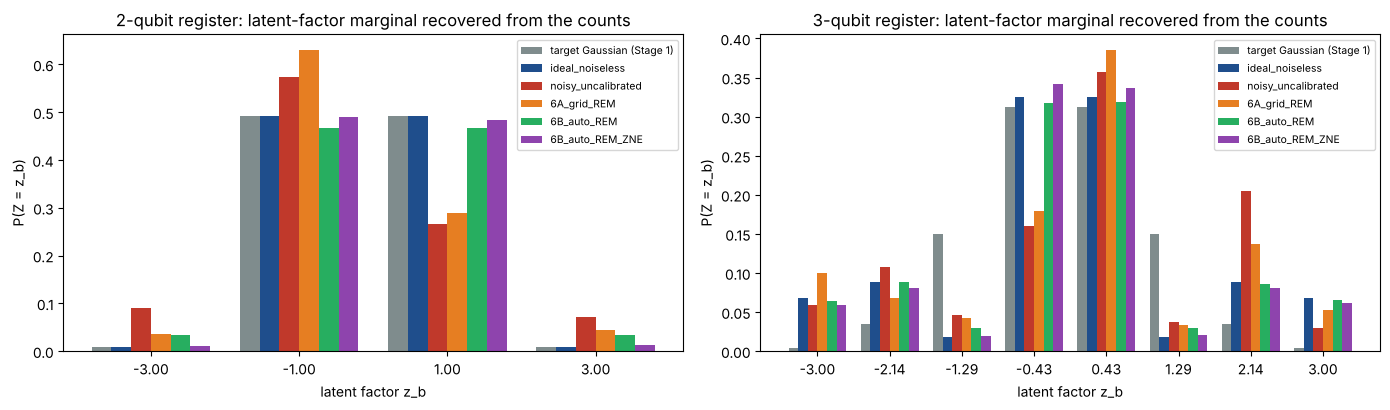

In [5]:
show = ["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    zg, target = target_gaussian_histogram(n, C.Z_MAX)
    w = 0.8 / (len(show) + 1)
    ax.bar(np.arange(2 ** n) - 0.4 + w / 2, target, w, color=GREY, label="target Gaussian (Stage 1)")
    for i, k in enumerate(show):
        ax.bar(np.arange(2 ** n) - 0.4 + (i + 1.5) * w, post[n]["variants"][k]["z_marginal"], w,
               color=COLORS[k], label=k)
    ax.set_xticks(range(2 ** n)); ax.set_xticklabels([f"{z:.2f}" for z in zg])
    ax.set_xlabel("latent factor z_b"); ax.set_ylabel("P(Z = z_b)")
    ax.set_title(f"{n}-qubit register: latent-factor marginal recovered from the counts")
    ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage08_latent_marginal.png"); plt.show()

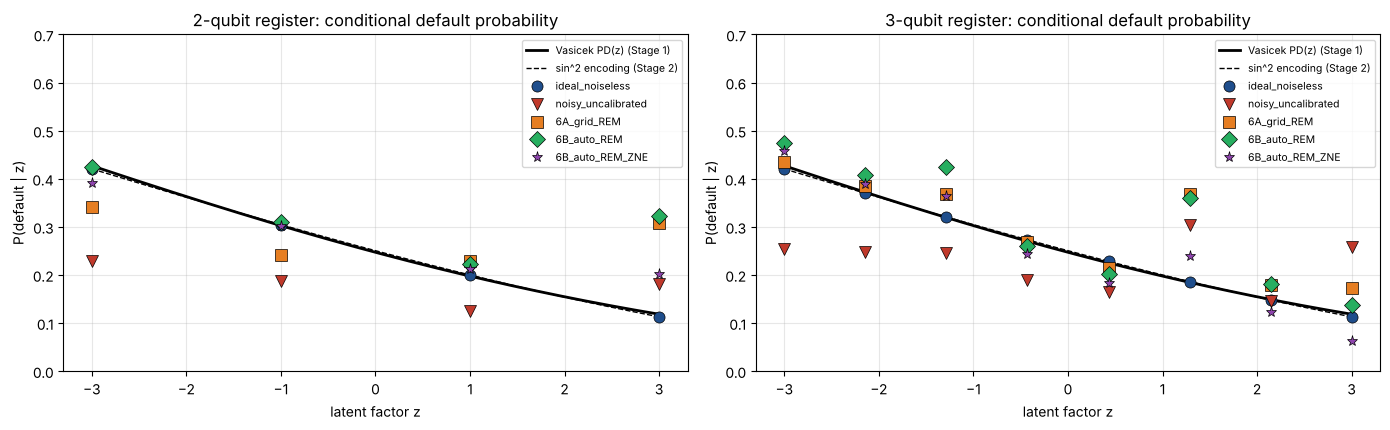

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, n in zip(axes, C.REGISTER_SIZES):
    zg = z_grid(n)
    zz = np.linspace(-C.Z_MAX, C.Z_MAX, 300)
    ax.plot(zz, pd_given_z(zz, C.P0, C.RHO), color="k", lw=2, label="Vasicek PD(z) (Stage 1)")
    a_t, b_t = enc[f"{n}_qubit"]["alpha_tilde"], enc[f"{n}_qubit"]["beta_tilde"]
    bb = (zz + C.Z_MAX) * (2 ** n - 1) / (2 * C.Z_MAX)
    ax.plot(zz, np.sin(a_t * bb + b_t) ** 2, color="k", ls="--", lw=1, label="sin^2 encoding (Stage 2)")
    for k, mk in zip(["ideal_noiseless", "noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"],
                     ["o", "v", "s", "D", "*"]):
        ax.plot(zg, post[n]["variants"][k]["conditional_pd"], mk, color=COLORS[k], ms=8, mec="k", mew=0.5, label=k)
    ax.set_xlabel("latent factor z"); ax.set_ylabel("P(default | z)")
    ax.set_title(f"{n}-qubit register: conditional default probability")
    ax.set_ylim(0, 0.7); ax.grid(alpha=0.3); ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage08_conditional_pd.png"); plt.show()

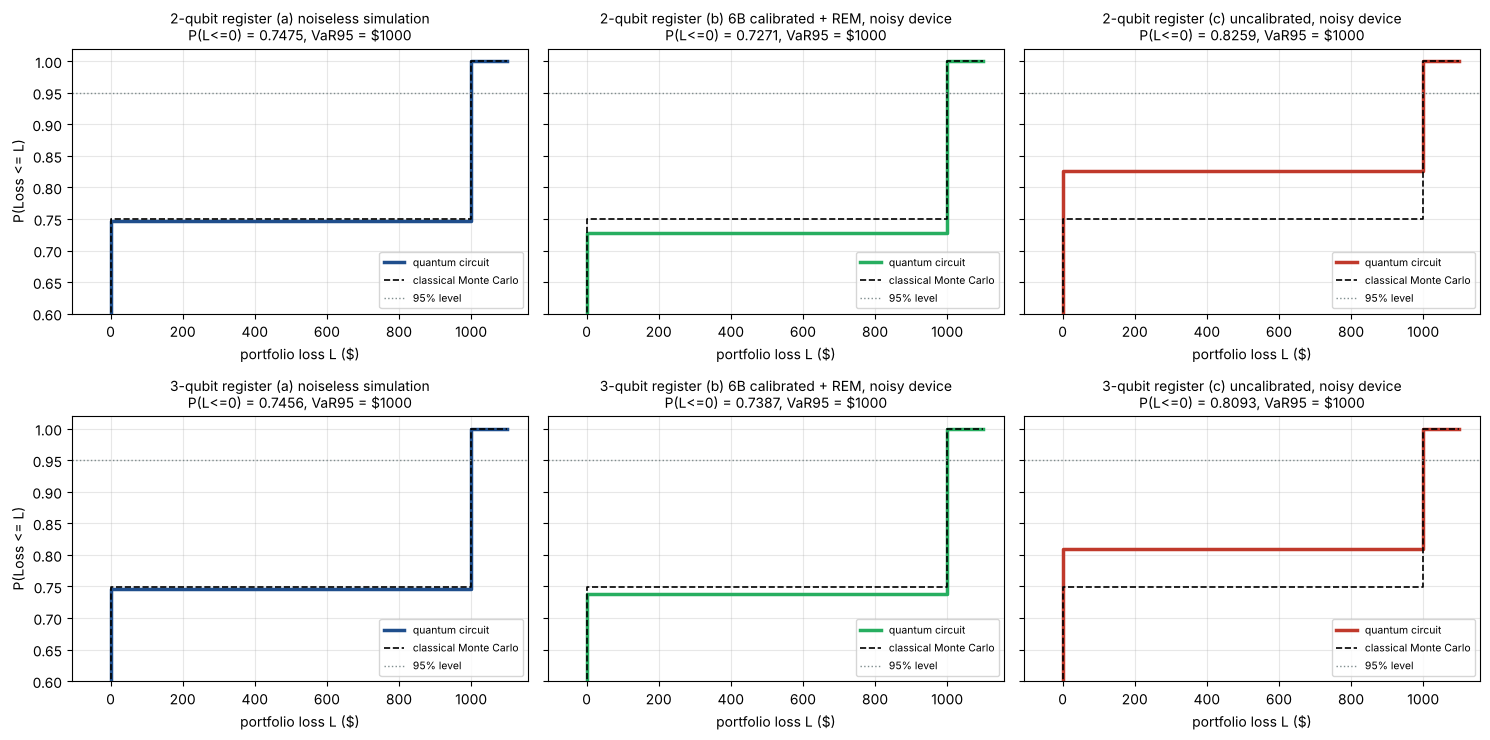

In [7]:
panels = [("ideal_noiseless", "(a) noiseless simulation"), ("6B_auto_REM", "(b) 6B calibrated + REM, noisy device"),
          ("noisy_uncalibrated", "(c) uncalibrated, noisy device")]
mc = post[2]["classical"]["classical_monte_carlo_continuous"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey=True)
for r, n in enumerate(C.REGISTER_SIZES):
    for ax, (k, title) in zip(axes[r], panels):
        v = post[n]["variants"][k]
        L = np.array(v["unique_losses"]); cdf = np.array(v["cdf"])
        ax.step(np.r_[-50, L, 1100], np.r_[0, cdf, 1], where="post", color=COLORS[k], lw=2.5, label="quantum circuit")
        ax.step(np.r_[-50, mc["unique_losses"], 1100], np.r_[0, mc["cdf"], 1], where="post",
                color="k", ls="--", lw=1.2, label="classical Monte Carlo")
        ax.axhline(C.CONFIDENCE, color=GREY, ls=":", lw=1, label="95% level")
        ax.set_title(f"{n}-qubit register {title}\nP(L<=0) = {cdf[0]:.4f}, VaR95 = ${v['var']:.0f}", fontsize=10)
        ax.set_xlabel("portfolio loss L ($)"); ax.set_ylim(0.6, 1.02); ax.grid(alpha=0.3)
        if ax is axes[r][0]:
            ax.set_ylabel("P(Loss <= L)")
        ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage08_loss_cdf.png"); plt.show()

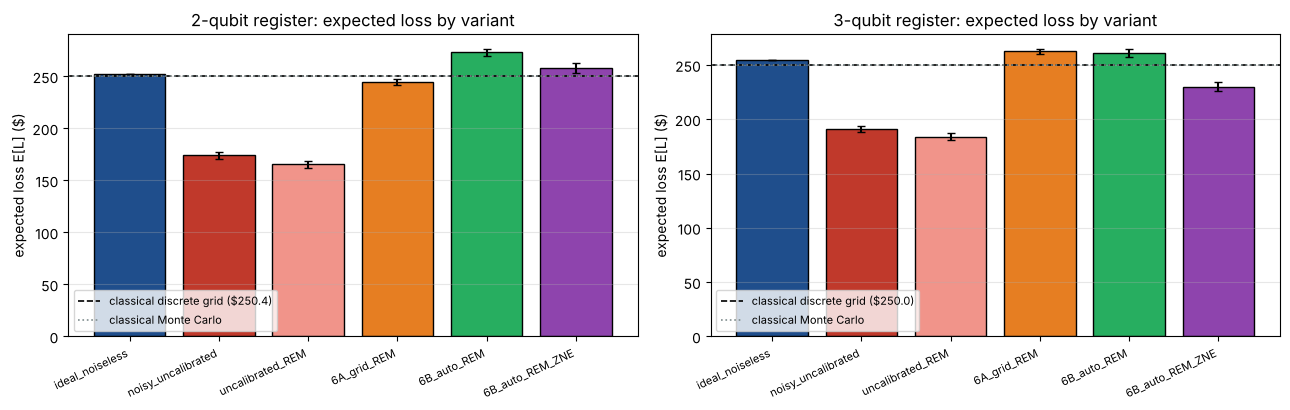

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
keys = list(post[2]["variants"])
for ax, n in zip(axes, C.REGISTER_SIZES):
    V = post[n]["variants"]
    el = [V[k]["expected_loss"] for k in keys]
    sd = [V[k]["expected_loss_std"] for k in keys]
    ax.bar(range(len(keys)), el, yerr=sd, capsize=3, color=[COLORS[k] for k in keys], edgecolor="k")
    cl = post[n]["classical"]["classical_discrete_grid"]["expected_loss"]
    ax.axhline(cl, color="k", ls="--", lw=1.2, label=f"classical discrete grid (${cl:.1f})")
    ax.axhline(post[n]["classical"]["classical_monte_carlo_continuous"]["expected_loss"], color=GREY, ls=":",
               lw=1.2, label="classical Monte Carlo")
    ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("expected loss E[L] ($)"); ax.set_title(f"{n}-qubit register: expected loss by variant")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig(fig, "stage08_expected_loss.png"); plt.show()

In [9]:
out = {f"{n}_qubit": post[n] for n in C.REGISTER_SIZES}
path = save_json(out, "stage08_postprocessing.json")
print(f"Saved -> {path}")

Saved -> /home/claude/repo/results/stage08_postprocessing.json
